# Dynamic LI/OV experiment with truncated mIBP dynamics

This notebook is the main experiment notebook under `dynamic/`. It compares the marginal predictive probability `P(US)` across LI/OV scenarios, where each scenario consists of 50 all-zero trials, an optional 50-trial `A-` latent-inhibition block, and a 50-trial final reinforced block (`AB+` when OV is present, `A+` otherwise). It also studies one `LI + OV` posterior in detail and saves the main figures plus latent-structure summaries to `outputs_updated/images/` and `outputs_updated/latent_data/`.


In [1]:
import importlib
import json
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import dynamic.ifhmm as ifhmm

importlib.reload(ifhmm)

from dynamic.ifhmm import (
    compare_li_ov_predictions,
    run_dynamic_li_ov_particle_filter,
    scenario_phase_slices,
    summarize_mode_aligned_features,
    summarize_phase_switches,
)

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)

OUTPUT_DATA_DIR = Path("outputs_updated") / "latent_data"
OUTPUT_IMAGE_DIR = Path("outputs_updated") / "images"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 45
N_RUNS = 4
RUN_SEEDS = [SEED + idx for idx in range(N_RUNS)]

LATENT_INHIBITION_START = 50
FINAL_PHASE_START = 100
REPORT_SWITCH_TIMES = [50, 100]

# Tuned within a strict IFHMM: shorter feature lifetimes, sparser masks,
# stronger emissions, and more aggressive rejuvenation.
settings = dict(
    final_phase_trials=50,
    n_particles=64,
    K=10,
    alpha=0.4,
    gamma=2.25,
    delta=4.25,
    rho=0.2,
    sigma_w=2.6,
    sigma_b=1.0,
    mu_b=(-6.5, -6.5, -6.5),
    init_n_iter=2500,
    init_burn=1200,
    latent_update_candidates=256,
    query_samples=256,
    ess_threshold_fraction=0.65,
    rejuvenation_sweeps_per_resample=2,
)


{"run_seeds": RUN_SEEDS, "settings": settings, "report_switch_times": REPORT_SWITCH_TIMES}


{'run_seeds': [45, 46, 47, 48],
 'settings': {'final_phase_trials': 50,
  'n_particles': 64,
  'K': 10,
  'alpha': 0.4,
  'gamma': 2.25,
  'delta': 4.25,
  'rho': 0.2,
  'sigma_w': 2.6,
  'sigma_b': 1.0,
  'mu_b': (-6.5, -6.5, -6.5),
  'init_n_iter': 2500,
  'init_burn': 1200,
  'latent_update_candidates': 256,
  'query_samples': 256,
  'ess_threshold_fraction': 0.65,
  'rejuvenation_sweeps_per_resample': 2},
 'report_switch_times': [50, 100]}

## Scenario comparison

Run the across-scenario sweep first so the saved marginal-probability curve reflects how `P(US)` changes as the final `A+` or `AB+` block accumulates under each LI/OV design.


[scenario 1/4 | run 1/4] No LI / No OV seed=45
[control run 1/4 seed=45] Initial posterior fit on 50 prefix trials (LI=False, OV=False)
[control run 1/4 seed=45] Initial fit complete. Starting sequential filter.
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 1.
[control run 1/4 seed=45] Filter progress 1/50 (ESS=64.0, mean occupied=2.78)
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 2.
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 3.
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 5.
[control run 1/4 seed=45] Filter progress 5/50 (ESS=64.0, mean occupied=3.52)
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 8.
[control run 1/4 seed=45] Filter progress 10/50 (ESS=52.3, mean occupied=3.64)
[control run 1/4 seed=45] Resampled/rejuvenated at final-phase trial 12.
[control run 1/4 seed=45] Filter progress 15/50 (ESS=55.7, mean occupied=3.63)
[control run 1/4 seed=45] Resampled/rejuv

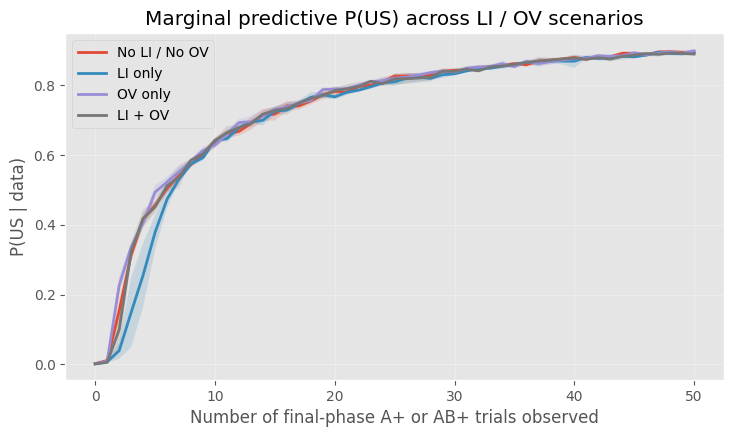

In [2]:
comparison = compare_li_ov_predictions(
    n_runs=N_RUNS,
    seeds=RUN_SEEDS,
    query_condition=None,
    verbose=True,
    **settings,
)

trial_counts = comparison["trial_counts"]
summary = comparison["summary"]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for scenario in comparison["scenario_order"]:
    name = scenario["name"]
    mean = summary[name]["mean"]
    std = summary[name]["std"]
    ax.plot(trial_counts, mean, linewidth=2.0, label=summary[name]["label"])
    ax.fill_between(trial_counts, mean - std, mean + std, alpha=0.18)

ax.set_xlabel("Number of final-phase A+ or AB+ trials observed")
ax.set_ylabel("P(US | data)")
ax.set_title("Marginal predictive P(US) across LI / OV scenarios")
ax.legend()
ax.grid(True, alpha=0.3)
comparison_fig_path = OUTPUT_IMAGE_DIR / "li_ov_marginal_us_curves.png"
fig.savefig(comparison_fig_path, dpi=200, bbox_inches="tight")
plt.show()


## Single-run LI + OV posterior summary

The next cells run one explicit `LI + OV` fit, summarize the aligned final latent structure, and then export the switching diagnostics used to interpret that structure over the baseline, LI, and final overshadowing phases.


In [3]:
li_ov_result = run_dynamic_li_ov_particle_filter(
    latent_inhibition=True,
    overshadowing=True,
    seed=SEED,
    snapshot_trials=[0, 10, 20, 30, 40, 50],
    verbose=True,
    **settings,
)

li_ov_result["resampled_at"]


[seed=45] Initial posterior fit on 100 prefix trials (LI=True, OV=True)


[seed=45] Initial fit complete. Starting sequential filter.
[seed=45] Resampled/rejuvenated at final-phase trial 1.
[seed=45] Filter progress 1/50 (ESS=64.0, mean occupied=3.06)
[seed=45] Resampled/rejuvenated at final-phase trial 2.
[seed=45] Resampled/rejuvenated at final-phase trial 3.
[seed=45] Resampled/rejuvenated at final-phase trial 5.
[seed=45] Filter progress 5/50 (ESS=64.0, mean occupied=4.17)
[seed=45] Resampled/rejuvenated at final-phase trial 8.
[seed=45] Filter progress 10/50 (ESS=51.4, mean occupied=4.51)
[seed=45] Resampled/rejuvenated at final-phase trial 12.
[seed=45] Filter progress 15/50 (ESS=54.2, mean occupied=4.31)
[seed=45] Resampled/rejuvenated at final-phase trial 19.
[seed=45] Filter progress 20/50 (ESS=62.9, mean occupied=4.45)
[seed=45] Filter progress 25/50 (ESS=53.5, mean occupied=4.42)
[seed=45] Resampled/rejuvenated at final-phase trial 30.
[seed=45] Filter progress 30/50 (ESS=64.0, mean occupied=4.34)
[seed=45] Filter progress 35/50 (ESS=58.7, mean oc

[1, 2, 3, 5, 8, 12, 19, 30, 47]

In [4]:
ACTIVE_COUNT_THRESHOLD = 5
OBSERVED_NODE_LABELS = ["A", "B", "US"]
EDGE_WEIGHT_THRESHOLD = 0.25

final_snapshot = li_ov_result["snapshots"][settings["final_phase_trials"]]
aligned = summarize_mode_aligned_features(
    particles=final_snapshot["particles"],
    weights=final_snapshot["weights"],
    active_count_threshold=ACTIVE_COUNT_THRESHOLD,
)

aligned_summary = {
    "mode_occupied_features": int(aligned["target_count"]),
    "particles_kept": int(aligned["sample_count"]),
    "reference_particle": int(aligned["reference_idx"]),
    "avg_bias": np.array(aligned["avg_bias"], dtype=float),
    "avg_vectors": np.array(aligned["avg_vectors"], dtype=float),
    "avg_occupancy": np.array(aligned["avg_occupancy"], dtype=float),
}

print({
    "mode_occupied_features": aligned_summary["mode_occupied_features"],
    "particles_kept": aligned_summary["particles_kept"],
    "reference_particle": aligned_summary["reference_particle"],
})
print("Aligned average effective weights (A, B, US):")
print(np.round(aligned_summary["avg_vectors"], 3))
print("Aligned average bias:")
print(np.round(aligned_summary["avg_bias"], 3))


{'mode_occupied_features': 4, 'particles_kept': 42, 'reference_particle': 23}
Aligned average effective weights (A, B, US):
[[10.146  0.56   0.365]
 [ 0.428  0.083  0.081]
 [ 0.007  0.031 -0.008]
 [ 0.013  9.187  9.064]]
Aligned average bias:
[-5.601 -5.998 -5.654]


## Final latent structure

Align the final posterior particles, summarize the active latent features, and save the LI+OV structure figure before moving to the switching diagnostics.


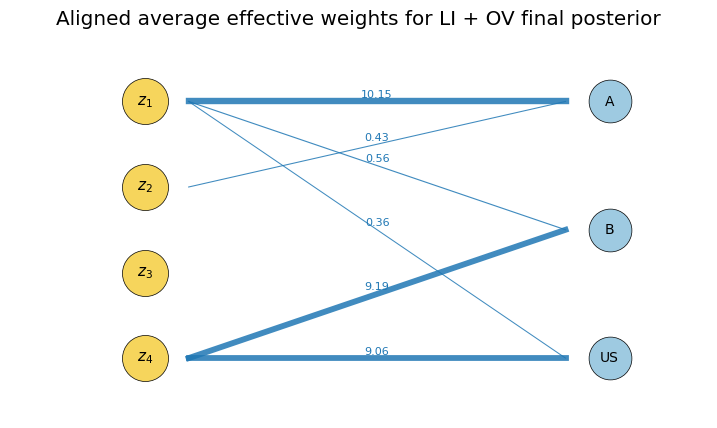

In [5]:
def plot_structure_schematic(ax, aligned_vectors):
    vectors = np.asarray(aligned_vectors, dtype=float)
    if vectors.shape[0] == 0:
        ax.text(0.5, 0.5, "No aligned latent structure", ha="center", va="center")
        ax.axis("off")
        return

    height = max(vectors.shape[0] - 1, len(OBSERVED_NODE_LABELS) - 1)
    latent_y = np.linspace(height, 0, vectors.shape[0])
    observed_y = np.linspace(height, 0, len(OBSERVED_NODE_LABELS))
    x_latent = 0.0
    x_observed = 1.9
    ax.set_xlim(-0.55, 2.3)
    ax.set_ylim(-0.7, height + 0.8)
    ax.axis("off")

    for idx, y_pos in enumerate(latent_y, start=1):
        ax.scatter(x_latent, y_pos, s=1100, color="#f6d55c", edgecolor="black", zorder=3)
        ax.text(x_latent, y_pos, rf"$z_{{{idx}}}$", ha="center", va="center", fontsize=11)

    for label, y_pos in zip(OBSERVED_NODE_LABELS, observed_y):
        ax.scatter(x_observed, y_pos, s=950, color="#9ecae1", edgecolor="black", zorder=3)
        ax.text(x_observed, y_pos, label, ha="center", va="center", fontsize=10)

    max_abs = np.max(np.abs(vectors)) if np.any(np.abs(vectors) > 0) else 1.0
    for latent_idx, y_latent in enumerate(latent_y):
        for obs_idx, y_observed in enumerate(observed_y):
            weight = vectors[latent_idx, obs_idx]
            if abs(weight) < EDGE_WEIGHT_THRESHOLD:
                continue
            color = "tab:blue" if weight > 0 else "tab:red"
            linewidth = 0.6 + 4.0 * abs(weight) / max_abs
            ax.plot([x_latent + 0.18, x_observed - 0.18], [y_latent, y_observed], color=color, linewidth=linewidth, alpha=0.85)
            ax.text((x_latent + x_observed) / 2, (y_latent + y_observed) / 2 + 0.08, f"{weight:.2f}", fontsize=8, ha="center", va="center", color=color)


fig, ax = plt.subplots(figsize=(9, 5))
plot_structure_schematic(ax, aligned_summary["avg_vectors"])
ax.set_title("Aligned average effective weights for LI + OV final posterior")
structure_fig_path = OUTPUT_IMAGE_DIR / "li_ov_aligned_structure.png"
fig.savefig(structure_fig_path, dpi=200, bbox_inches="tight")
plt.show()


## Switching diagnostics and saved outputs

This section summarizes how the aligned features switch across the baseline, latent-inhibition, and final overshadowing phases and writes the main findings to JSON and text outputs.


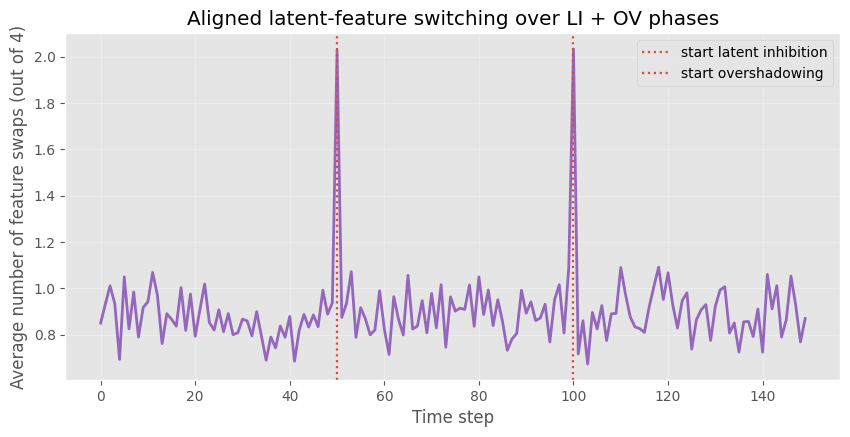

Mean switch count by phase:
{'baseline': 0.8695884269724421, 'latent_inhibition': 0.9178633411662793, 'overshadowing': 0.9114364157975036}
Correlation of switch-count trajectory with phase indicators:
{'baseline': -0.13135367341395013, 'latent_inhibition': 0.07972765333073027, 'overshadowing': 0.05162602008321986}
Correlation with phase-boundary indicator: 0.8126840390347082

Feature switch reports at requested thresholds:

Switch report at t=50
  Turning ON (off -> on tendency):
    slot 1: switch_prob=1.000, activation 0.000 -> 1.000, weights=[10.146, 0.56, 0.365]
  Turning OFF (on -> off tendency):
    slot 2: switch_prob=0.430, activation 0.454 -> 0.345, weights=[0.428, 0.083, 0.081]
  Mixed / ambiguous changes:
    slot 3: switch_prob=0.598, activation 0.355 -> 0.398, weights=[0.007, 0.031, -0.008]

Switch report at t=100
  Turning ON (off -> on tendency):
    slot 4: switch_prob=1.000, activation 0.000 -> 1.000, weights=[0.013, 9.187, 9.064]
  Turning OFF (on -> off tendency):
  

In [6]:
phase_slices = scenario_phase_slices(
    True,
    True,
    settings["final_phase_trials"],
    latent_inhibition_start=LATENT_INHIBITION_START,
    final_phase_start=FINAL_PHASE_START,
)
switch_summary = summarize_phase_switches(
    aligned_summary=aligned,
    phase_slices=phase_slices,
    switch_prob_threshold=0.2,
    activation_delta_threshold=0.05,
)

time_points = np.arange(len(switch_summary["switch_count_by_time"]))
n_aligned_features = aligned_summary["avg_vectors"].shape[0]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time_points, switch_summary["switch_count_by_time"], linewidth=2.0, color="tab:purple")
for xpos, label in [
    (LATENT_INHIBITION_START, "start latent inhibition"),
    (FINAL_PHASE_START, "start overshadowing"),
]:
    ax.axvline(xpos, linestyle=":", linewidth=1.6, label=label)
ax.set_xlabel("Time step")
ax.set_ylabel(f"Average number of feature swaps (out of {n_aligned_features})")
ax.set_title("Aligned latent-feature switching over LI + OV phases")
ax.grid(True, alpha=0.3)
ax.legend()
switch_fig_path = OUTPUT_IMAGE_DIR / "li_ov_switching.png"
fig.savefig(switch_fig_path, dpi=200, bbox_inches="tight")
plt.show()

activation = np.asarray(aligned["avg_activation_by_time"], dtype=float)
switch_prob = np.asarray(aligned["avg_switch_prob_by_time"], dtype=float)
vectors = np.asarray(aligned["avg_vectors"], dtype=float)

print("Mean switch count by phase:")
print(switch_summary["phase_mean_switch_count"])
print("Correlation of switch-count trajectory with phase indicators:")
print(switch_summary["phase_switch_correlation"])
print("Correlation with phase-boundary indicator:", switch_summary["boundary_correlation"])

switch_reports = []
for t in REPORT_SWITCH_TIMES:
    report = {"time": int(t), "status": "ok", "turning_on": [], "turning_off": [], "mixed": []}
    if t <= 0 or t >= activation.shape[0]:
        report["status"] = "outside_range"
        switch_reports.append(report)
        continue

    delta_activation = activation[t] - activation[t - 1]
    interesting = np.flatnonzero((switch_prob[t] >= 0.2) | (np.abs(delta_activation) >= 0.05))
    if interesting.size == 0:
        report["status"] = "no_threshold_crossings"
        switch_reports.append(report)
        continue

    for idx in interesting:
        item = {
            "feature": int(idx + 1),
            "switch_prob": float(switch_prob[t, idx]),
            "activation_before": float(activation[t - 1, idx]),
            "activation_after": float(activation[t, idx]),
            "weights": np.round(vectors[idx], 3).tolist(),
        }
        if delta_activation[idx] > 0.05:
            report["turning_on"].append(item)
        elif delta_activation[idx] < -0.05:
            report["turning_off"].append(item)
        else:
            report["mixed"].append(item)
    switch_reports.append(report)

print("\nFeature switch reports at requested thresholds:")
for report in switch_reports:
    print(f"\nSwitch report at t={report['time']}")
    if report["status"] == "outside_range":
        print("  outside the available time range")
        continue
    if report["status"] == "no_threshold_crossings":
        print("  no aligned slots crossed the reporting thresholds")
        continue

    if report["turning_on"]:
        print("  Turning ON (off -> on tendency):")
        for item in report["turning_on"]:
            print(
                f"    slot {item['feature']}: switch_prob={item['switch_prob']:.3f}, "
                f"activation {item['activation_before']:.3f} -> {item['activation_after']:.3f}, "
                f"weights={item['weights']}"
            )
    if report["turning_off"]:
        print("  Turning OFF (on -> off tendency):")
        for item in report["turning_off"]:
            print(
                f"    slot {item['feature']}: switch_prob={item['switch_prob']:.3f}, "
                f"activation {item['activation_before']:.3f} -> {item['activation_after']:.3f}, "
                f"weights={item['weights']}"
            )
    if report["mixed"]:
        print("  Mixed / ambiguous changes:")
        for item in report["mixed"]:
            print(
                f"    slot {item['feature']}: switch_prob={item['switch_prob']:.3f}, "
                f"activation {item['activation_before']:.3f} -> {item['activation_after']:.3f}, "
                f"weights={item['weights']}"
            )

summary_json_path = OUTPUT_DATA_DIR / "li_ov_dynamic_summary.json"
findings_txt_path = OUTPUT_DATA_DIR / "li_ov_dynamic_findings.txt"


def to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, dict):
        return {key: to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_serializable(value) for value in obj]
    return obj


payload = {
    "settings": settings,
    "run_seeds": RUN_SEEDS,
    "comparison_summary": summary,
    "resampled_at": li_ov_result["resampled_at"],
    "aligned_structure": {
        "mode_occupied_features": aligned_summary["mode_occupied_features"],
        "particles_kept": aligned_summary["particles_kept"],
        "reference_particle": aligned_summary["reference_particle"],
        "avg_bias": aligned_summary["avg_bias"].tolist(),
        "avg_vectors": aligned_summary["avg_vectors"].tolist(),
        "avg_occupancy": aligned_summary["avg_occupancy"].tolist(),
    },
    "phase_switch_summary": switch_summary,
    "switch_reports": switch_reports,
    "image_outputs": {
        "comparison": str(comparison_fig_path),
        "structure": str(structure_fig_path),
        "switching": str(switch_fig_path),
    },
}
with summary_json_path.open("w") as f:
    json.dump(to_serializable(payload), f, indent=2)

with findings_txt_path.open("w") as f:
    f.write("Dynamic LI/OV marginal-US particle-filter experiment\n")
    f.write("Settings:\n")
    for key, value in settings.items():
        f.write(f"  {key}: {value}\n")
    f.write(f"  run_seeds: {RUN_SEEDS}\n")
    f.write(f"  resampled_at: {li_ov_result['resampled_at']}\n")
    f.write("\nScenario marginal-US summaries:\n")
    for scenario in comparison["scenario_order"]:
        name = scenario["name"]
        f.write(
            f"  {summary[name]['label']}: final_mean={summary[name]['mean'][-1]:.4f}, final_std={summary[name]['std'][-1]:.4f}\n"
        )
    f.write("\nAligned LI + OV final structure:\n")
    f.write(f"  active_features: {aligned_summary['mode_occupied_features']}\n")
    f.write(f"  particles_kept: {aligned_summary['particles_kept']}\n")
    f.write(f"  avg_bias: {np.array2string(aligned_summary['avg_bias'], precision=3)}\n")
    f.write(f"  aligned_effective_weights:\n{np.array2string(aligned_summary['avg_vectors'], precision=3)}\n")
    f.write(f"  aligned_occupancy:\n{np.array2string(aligned_summary['avg_occupancy'], precision=3)}\n")
    f.write("\nSwitch reports:\n")
    for report in switch_reports:
        f.write(f"  t={report['time']} status={report['status']}\n")
        for label in ["turning_on", "turning_off", "mixed"]:
            if not report[label]:
                continue
            f.write(f"    {label}:\n")
            for item in report[label]:
                f.write(
                    f"      z_{item['feature']}: switch_prob={item['switch_prob']:.3f}, activation={item['activation_before']:.3f}->{item['activation_after']:.3f}, weights={item['weights']}\n"
                )
    f.write("\nSaved figures:\n")
    f.write(f"  comparison: {comparison_fig_path}\n")
    f.write(f"  structure: {structure_fig_path}\n")
    f.write(f"  switching: {switch_fig_path}\n")

print({
    "summary_json": str(summary_json_path),
    "findings_txt": str(findings_txt_path),
    "comparison": str(comparison_fig_path),
    "structure": str(structure_fig_path),
    "switching": str(switch_fig_path),
})
